# 0018SAM — cold chain

RAMP calibration notebook. To study another client, edit the two
lines of the next cell and run everything again.

In [1]:
CLIENT = "0018SAM"
PUE_TYPE = "cold_chain"

# Study period to calibrate on (the meter file may hold more days than the
# appliance's service period; set both to None to use the whole file).
# Cut on 2024-01-31 (diagnostic of 2026-08-26, validated): the only
# sustained cold regime of the record is Dec 2023 - Jan 2024; from
# Feb 2024 to Sep 2025 the appliance stays essentially unplugged
# (72 % inactive days), and Oct 2025 starts a different appliance
# (peaks 410-430 W vs 220 W). Caveat: the official SAM service start
# is 2024-02-01, so this window predates it - single Dry-season
# model, short record, declared as a limitation.
PERIOD_START = "2023-12-11"
PERIOD_END = "2024-01-31"

# Appliance rated power in W, used as a physical ceiling in the
# calibration (set to None to disable the cap).
RATED_POWER_W = 496

In [2]:
import json
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

REPO = Path.cwd().resolve().parents[1]      # notebooks/<type>/ -> repository root
sys.path.append(str(REPO / "src"))
import run

RESULTS = REPO / "resultats" / PUE_TYPE / CLIENT
FIGURES = RESULTS / "figures"


def show(*patterns):
    """Display every figure matching the given file patterns, in order."""
    for pattern in patterns:
        for path in sorted(FIGURES.glob(pattern)):
            display(Image(filename=str(path), width=900))

## Run the full chain

The next cell runs the six steps (preprocessing, clustering,
calibration, figures, summary) on this client. Progress appears
below as it happens; the whole chain takes about 10 to 15 minutes.

In [3]:
run.run(PUE_TYPE, CLIENT, period_start=PERIOD_START,
        period_end=PERIOD_END, rated_power_W=RATED_POWER_W)

[step1] 0018SAM: 39 active days kept, 1 inactive, 12 rejected, 50 outages -> resultats/cold_chain/0018SAM


[step2] 0018SAM: 1 clusters, 1 noise days, 1 seasonal targets


[step3] 0018SAM: 12 clustering figures -> resultats/cold_chain/0018SAM/figures


[step4] Dry season: p1 233 W  p2 4.0 W  t_on 14 min  [00h-07h d=0.52, 07h-16h d=0.16, 16h-24h d=0.57]


[step5] Dry season: cap 0.33  zero 4/6 NRMSE 0.226  act 4/6 NRMSE 0.237


[step6] Dry season: screened  3 regions  L 22 min  tfrv 0.72  amp 1.07  rescue 1


[step7] Dry season: fit 4/6  NRMSE 0.232+/-0.005  holdout 0.291 (floor 0.217)


[step8] 0018SAM: calibration figures -> resultats/cold_chain/0018SAM/figures


[step9] cold_chain: 12 client-seasons, criteria passed 49/72


## Client identity card

In [4]:
clean = pd.read_csv(RESULTS / "timeseries_clean.csv", index_col=0,
                    parse_dates=True)
daily = pd.read_csv(RESULTS / "daily_matrix_W.csv", index_col=0,
                    parse_dates=True)
kept = pd.read_csv(RESULTS / "clustered_features.csv", index_col=0)
card = pd.Series({
    "Client": CLIENT,
    "PUE type": PUE_TYPE.replace("_", " "),
    "Site": "Samionta" if CLIENT.endswith("SAM") else "Gbowele",
    "Rated power (W)": RATED_POWER_W if RATED_POWER_W else "-",
    "Study period": f"{PERIOD_START} to {PERIOD_END}",
    "Raw days with data": int(pd.Series(clean.index.normalize()).nunique()),
    "Complete days (96 slots)": len(daily),
    "Days kept after filtering": len(kept),
})
card.to_frame("value")

,value
Client,0018SAM
PUE type,cold chain
Site,Samionta
Rated power (W),496
Study period,2023-12-11 to 2024-01-31
Raw days with data,52
Complete days (96 slots),39
Days kept after filtering,39


## Measured seasonal profiles and day-by-hour heatmap and activity timeline

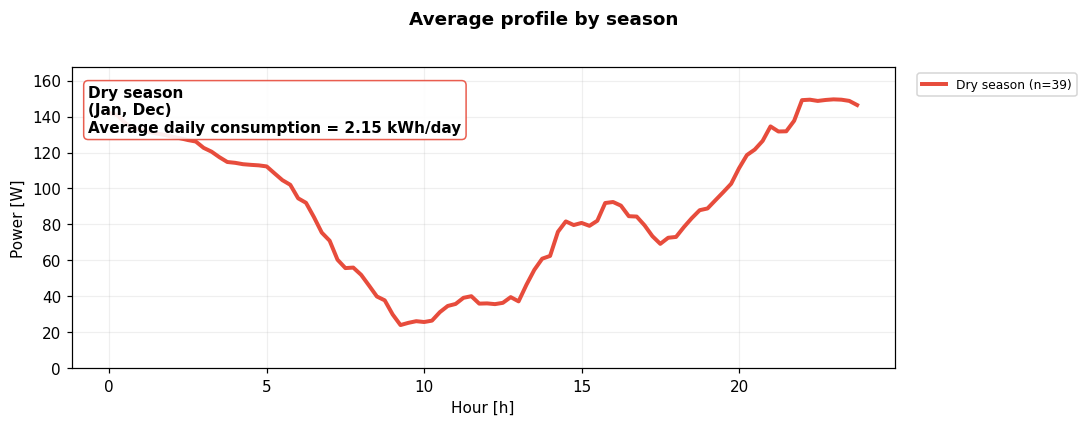

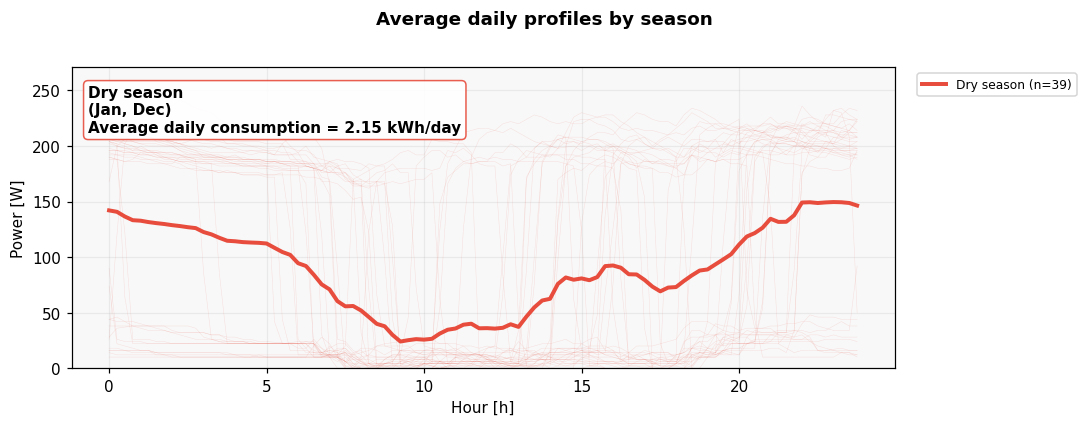

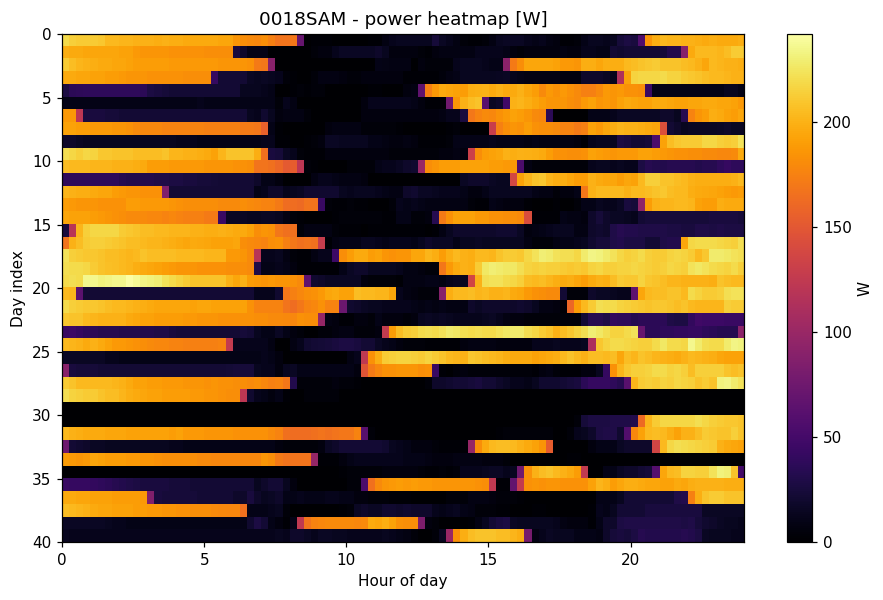

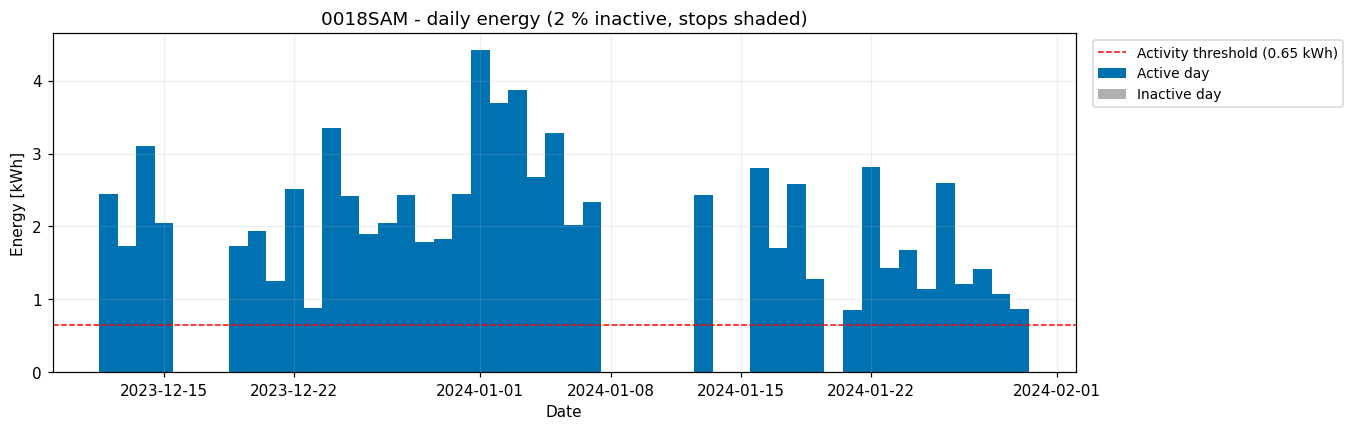

In [5]:
show("07_season_profiles.png", "07b_season_profiles_stacked.png",
     "0*_heatmap.png", "03_activity_timeline.png")

## Clustering

k-distance heuristic, cluster sizes, cluster profiles, feature
scatters and the season/cluster distribution.

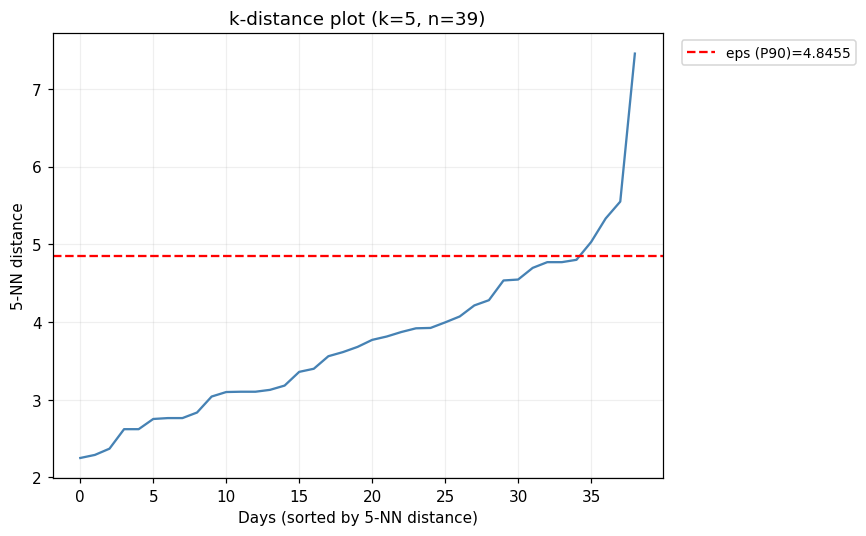

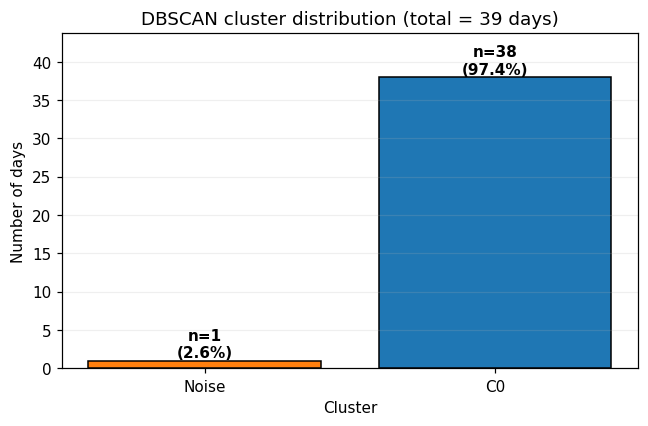

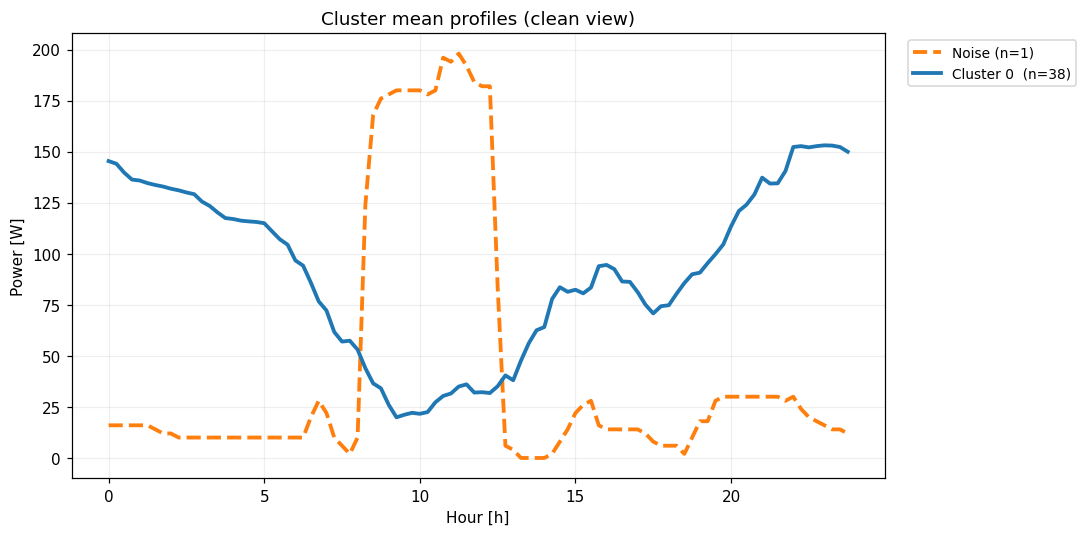

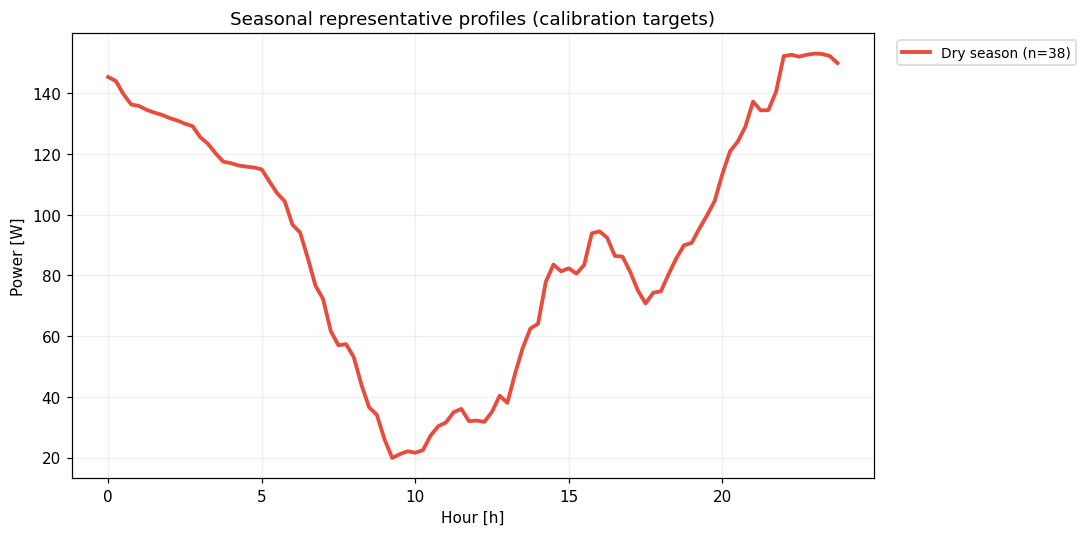

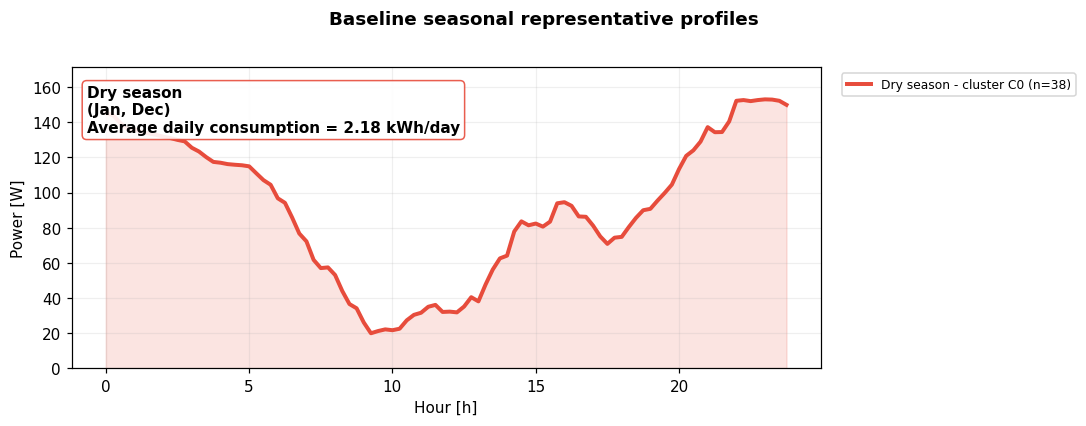

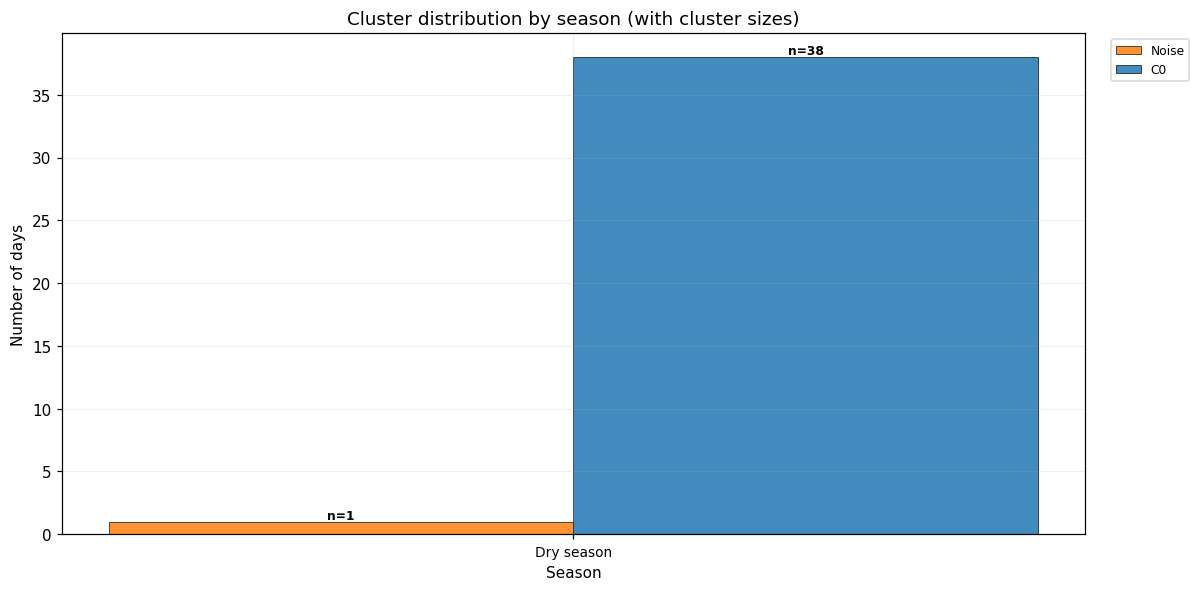

In [6]:
show("08_k_distance_plot.png", "0*_cluster_histogram.png",
     "*_cluster_profiles*.png", "*repr*.png",
     "12_scatter_E_Ppeak.png", "13_scatter_E_LF.png",
     "14_scatter_Ppeak_peakH.png", "15_season_cluster_bar.png")

## Dry season

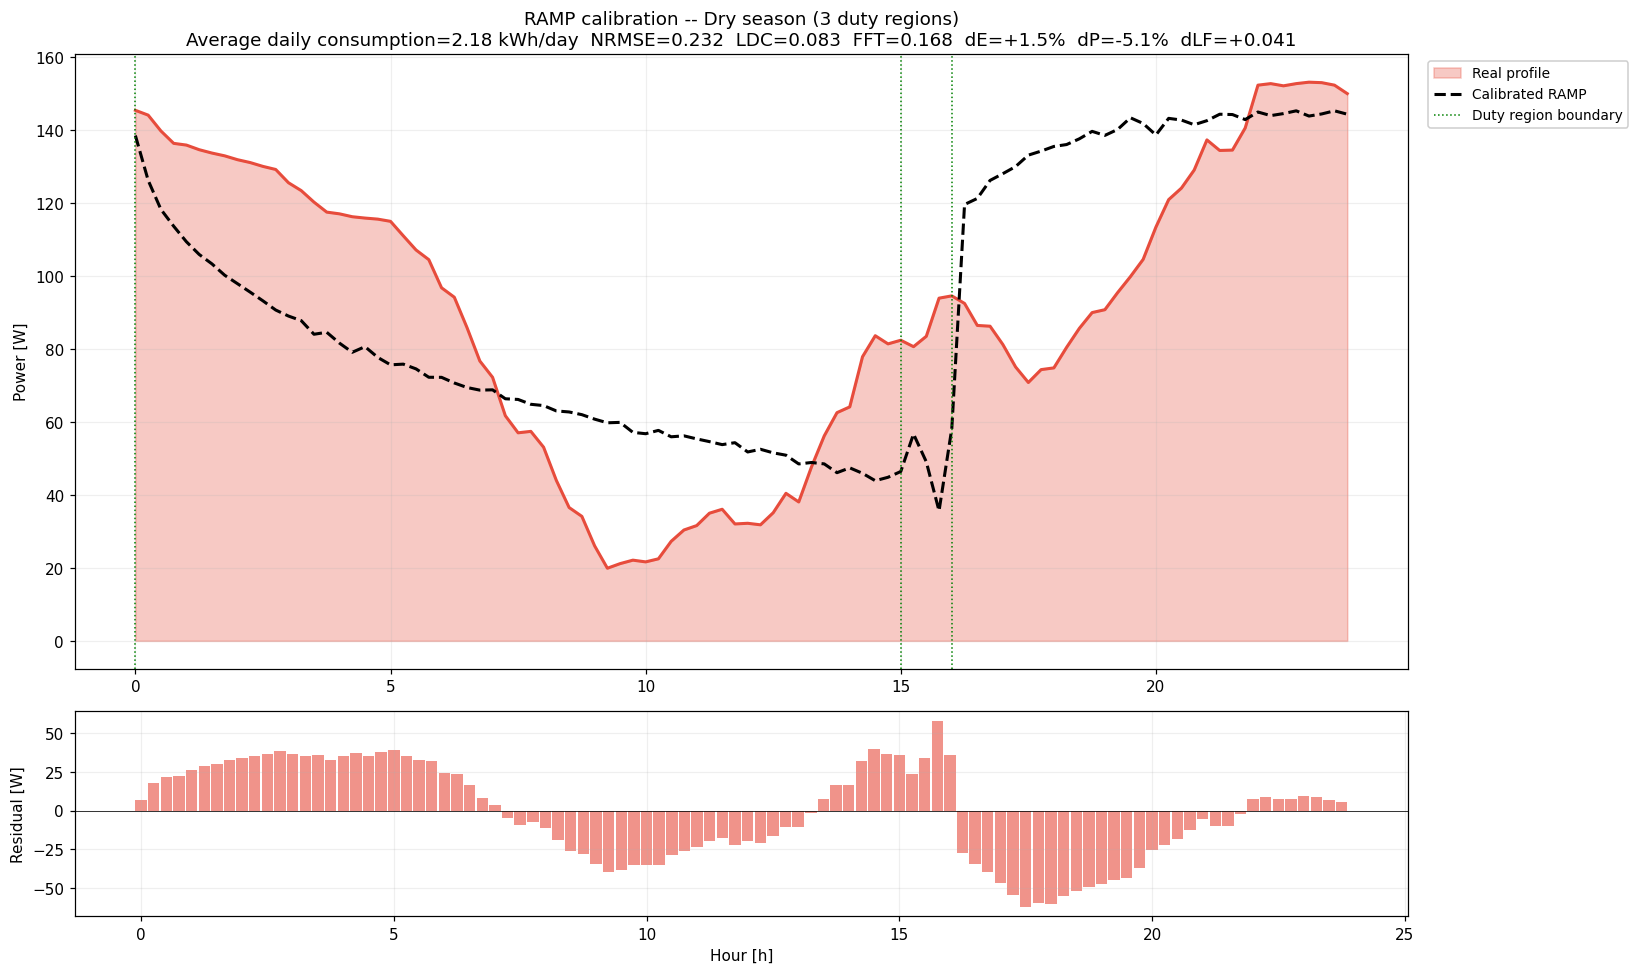

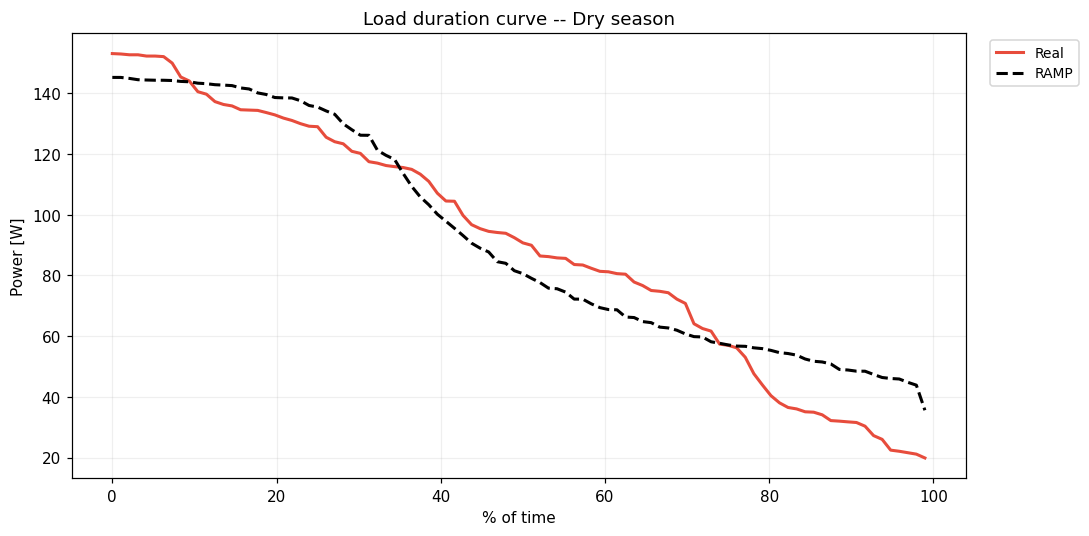

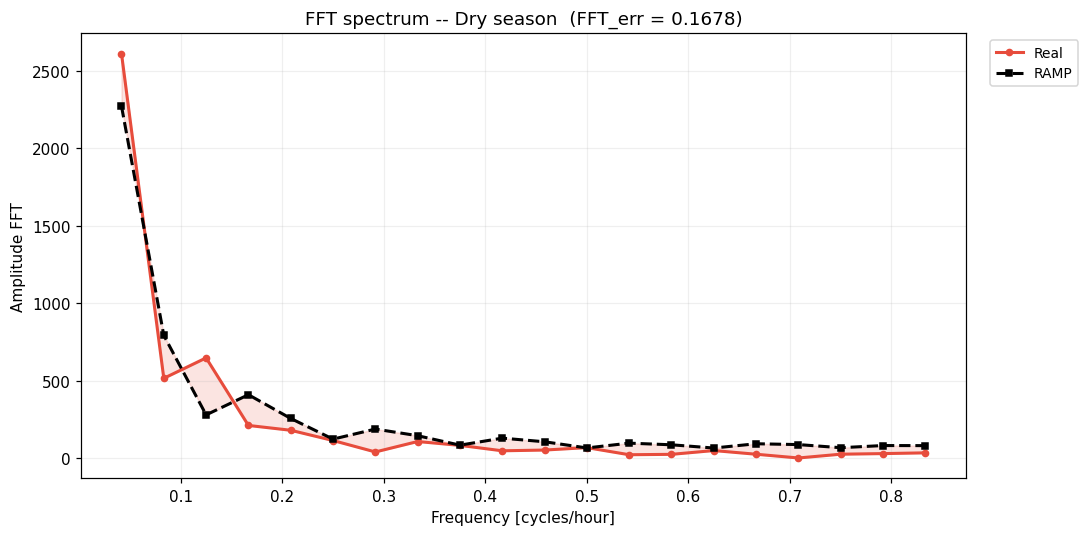

,season,n_pass,NRMSE,LDC_err,FFT_err,err_E_pct,err_P_pct,err_LF
0,Dry season,4,0.232,0.083,0.168,1.483,-5.126,0.041


In [7]:
season = "Dry season"
val = pd.read_csv(RESULTS / "validation_metrics.csv")
row = val[val["season"] == season]
if row.empty:
    print("No calibration for this season (not enough measured days).")
else:
    show(f"40_calib_Dry_season.png", f"41_ldc_Dry_season.png", f"42_fft_Dry_season.png")
    wanted = ["season", "n_pass", "NRMSE", "LDC_err", "FFT_err",
              "err_E_pct", "err_P_pct", "err_LF"]
    cols = [c for c in wanted if c in row.columns]
    display(row[cols].round(3))

## May

In [8]:
season = "May"
val = pd.read_csv(RESULTS / "validation_metrics.csv")
row = val[val["season"] == season]
if row.empty:
    print("No calibration for this season (not enough measured days).")
else:
    show(f"40_calib_May.png", f"41_ldc_May.png", f"42_fft_May.png")
    wanted = ["season", "n_pass", "NRMSE", "LDC_err", "FFT_err",
              "err_E_pct", "err_P_pct", "err_LF"]
    cols = [c for c in wanted if c in row.columns]
    display(row[cols].round(3))

No calibration for this season (not enough measured days).


## Rainy season

In [9]:
season = "Rainy season"
val = pd.read_csv(RESULTS / "validation_metrics.csv")
row = val[val["season"] == season]
if row.empty:
    print("No calibration for this season (not enough measured days).")
else:
    show(f"40_calib_Rainy_season.png", f"41_ldc_Rainy_season.png", f"42_fft_Rainy_season.png")
    wanted = ["season", "n_pass", "NRMSE", "LDC_err", "FFT_err",
              "err_E_pct", "err_P_pct", "err_LF"]
    cols = [c for c in wanted if c in row.columns]
    display(row[cols].round(3))

No calibration for this season (not enough measured days).


## October

In [10]:
season = "October"
val = pd.read_csv(RESULTS / "validation_metrics.csv")
row = val[val["season"] == season]
if row.empty:
    print("No calibration for this season (not enough measured days).")
else:
    show(f"40_calib_October.png", f"41_ldc_October.png", f"42_fft_October.png")
    wanted = ["season", "n_pass", "NRMSE", "LDC_err", "FFT_err",
              "err_E_pct", "err_P_pct", "err_LF"]
    cols = [c for c in wanted if c in row.columns]
    display(row[cols].round(3))

No calibration for this season (not enough measured days).


## Calibrated RAMP parameters

,season,method_arm,p1_W,p2_W,n_regions,cycle_len_min,func_time_min,func_cycle_min,thermal_p_var,tfrv,...,region1_t_on_min,region1_t_off_min,region2_window,region2_duty,region2_t_on_min,region2_t_off_min,region3_window,region3_duty,region3_t_on_min,region3_t_off_min
0,Dry season,screened,232.6,4.0,3,22,1440,22,0.1,0.722,...,5,17,900-960,0.262,6,16,960-1440,0.701,15,7


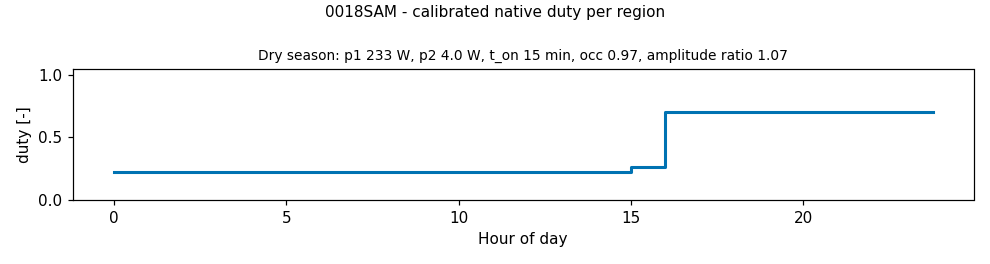

In [11]:
params = pd.read_csv(RESULTS / "appliance_parameters.csv")
display(params.round(3))
show("50_param_summary.png")